# Fixed vs Trainable B: Ablation on the Coupling Channel

How much does **training B** matter? We compare four settings:

1. **Baseline** — no factors, Adam
2. **Split (trainable B)** — standard: both B and C are trainable
3. **Split (fixed B)** — B is frozen at its random init, only C is trainable
4. **Split (rerandomized B each epoch)** — B is frozen and re-randomized every epoch, only C is trainable

Settings 3 and 4 test whether the coupling structure $P = I + BB^\top$ needs to be learned or if random coupling suffices.

In [1]:
import sys
sys.path.insert(0, "../src")

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import copy

from WeightDecomp import DecomposedLinear, DecomposedMLP
from WeightDecomp.train_mnist import train_epoch, evaluate, reset_factor_optimizer_state

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
train_set = torchvision.datasets.MNIST(root="../data", train=True, transform=transform, download=False)
test_set = torchvision.datasets.MNIST(root="../data", train=False, transform=transform, download=False)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=256)

In [3]:
@torch.no_grad()
def count_dead_neurons(model, loader, device, max_batches=50):
    model.eval()
    layers = model.decomposed_layers()
    hidden_layers = layers[:-1]
    max_preact = [torch.full((l.out_features,), -float("inf"), device=device) for l in hidden_layers]
    for batch_idx, (images, _) in enumerate(loader):
        if batch_idx >= max_batches:
            break
        x = images.to(device).view(images.size(0), -1)
        for i, layer in enumerate(hidden_layers):
            preact = layer(x)
            max_preact[i] = torch.maximum(max_preact[i], preact.max(dim=0).values)
            x = F.relu(preact)
    return {i: (int((mp < 0).sum()), mp.numel()) for i, mp in enumerate(max_preact)}


def kill_neurons(model, frac=0.5, bias_val=-5.0, seed=123):
    rng = torch.Generator().manual_seed(seed)
    for layer in model.decomposed_layers()[:-1]:
        n = layer.out_features
        n_kill = int(n * frac)
        kill_idx = torch.randperm(n, generator=rng)[:n_kill]
        with torch.no_grad():
            layer.bias.data[kill_idx] = bias_val
        print(f"  Killed {n_kill}/{n} neurons (bias <- {bias_val})")

In [4]:
def freeze_B(model):
    """Freeze all B parameters (set requires_grad=False)."""
    for layer in model.decomposed_layers():
        for B in layer.Bs:
            B.requires_grad_(False)


def rerandomize_B(model):
    """Re-randomize all B parameters in-place (Kaiming uniform)."""
    import math
    with torch.no_grad():
        for layer in model.decomposed_layers():
            for B in layer.Bs:
                nn.init.kaiming_uniform_(B, a=math.sqrt(5))

## Create Base Model, Kill Neurons, and Shared Warmup

In [5]:
torch.manual_seed(42)
layer_sizes = [784, 64, 32, 10]

base_model = DecomposedMLP(layer_sizes).to(device)
print("Killing neurons:")
kill_neurons(base_model, frac=0.5, bias_val=-5.0)

dead_init = count_dead_neurons(base_model, train_loader, device)
for i, (d, t) in dead_init.items():
    print(f"  Layer {i}: {d}/{t} dead ({100*d/t:.0f}%)")

WARMUP_EPOCHS = 2
optimizer = torch.optim.Adam(base_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

warmup_dead = [count_dead_neurons(base_model, train_loader, device)]
warmup_losses = []
warmup_accs = []

print(f"\n--- Shared warmup ({WARMUP_EPOCHS} epochs) ---")
for epoch in range(1, WARMUP_EPOCHS + 1):
    train_loss, _ = train_epoch(base_model, train_loader, optimizer, criterion, device)
    test_acc = evaluate(base_model, test_loader, device)
    warmup_losses.append(train_loss)
    warmup_accs.append(test_acc)
    warmup_dead.append(count_dead_neurons(base_model, train_loader, device))
    dead_str = ", ".join(f"L{i}: {d}/{t}" for i, (d, t) in warmup_dead[-1].items())
    print(f"Epoch {epoch} | Loss: {train_loss:.4f} | Test: {100*test_acc:.2f}% | Dead: [{dead_str}]")

print("\nNow we fork.")

Killing neurons:
  Killed 32/64 neurons (bias <- -5.0)
  Killed 16/32 neurons (bias <- -5.0)
  Layer 0: 32/64 dead (50%)
  Layer 1: 16/32 dead (50%)

--- Shared warmup (2 epochs) ---
Epoch 1 | Loss: 0.5635 | Test: 92.00% | Dead: [L0: 36/64, L1: 14/32]
Epoch 2 | Loss: 0.2412 | Test: 93.84% | Dead: [L0: 36/64, L1: 11/32]

Now we fork.


## Training Function

In [6]:
def continue_training(base_model, ranks=None, epochs=40, lr=1e-3,
                      merge_resplit_every=None, freeze_B_flag=False,
                      rerandomize_B_each_epoch=False):
    """Fork from warmed-up model and continue training.

    freeze_B_flag: if True, B is not trainable (only C learns)
    rerandomize_B_each_epoch: if True, B is re-randomized before each epoch
                              (implies freeze_B_flag)
    """
    model = copy.deepcopy(base_model)
    if ranks:
        model.split_all(ranks)

    if freeze_B_flag or rerandomize_B_each_epoch:
        freeze_B(model)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    dead_counts = [count_dead_neurons(model, train_loader, device)]
    train_losses = []
    test_accs = []

    for epoch in range(1, epochs + 1):
        # Merge + resplit
        if (merge_resplit_every and ranks
                and epoch > 1 and (epoch - 1) % merge_resplit_every == 0):
            model.merge_all(rerandomize_B=True)
            if freeze_B_flag or rerandomize_B_each_epoch:
                freeze_B(model)
            reset_factor_optimizer_state(optimizer, model)
            print(f"  [Merge + resplit at post-warmup epoch {epoch}]")

        # Re-randomize B each epoch (fresh random coupling directions)
        if rerandomize_B_each_epoch and ranks:
            rerandomize_B(model)

        train_loss, _ = train_epoch(model, train_loader, optimizer, criterion, device)
        test_acc = evaluate(model, test_loader, device)
        train_losses.append(train_loss)
        test_accs.append(test_acc)
        dead_counts.append(count_dead_neurons(model, train_loader, device))

        if epoch % 5 == 0 or epoch == 1:
            dead_str = ", ".join(f"L{i}: {d}/{t}" for i, (d, t) in dead_counts[-1].items())
            print(f"Epoch {epoch:3d} | Loss: {train_loss:.4f} | "
                  f"Test: {100*test_acc:.2f}% | Dead: [{dead_str}]")

    return {"dead_counts": dead_counts, "train_losses": train_losses, "test_accs": test_accs}

## Experiment 1: Baseline (no factors)

In [7]:
POST_EPOCHS = 40
RANKS = [4, 8]
MERGE_EVERY = 10

print("=== Baseline ===")
baseline = continue_training(base_model, epochs=POST_EPOCHS)

=== Baseline ===
Epoch   1 | Loss: 0.1961 | Test: 94.63% | Dead: [L0: 36/64, L1: 12/32]
Epoch   5 | Loss: 0.1207 | Test: 96.11% | Dead: [L0: 36/64, L1: 7/32]
Epoch  10 | Loss: 0.0824 | Test: 96.41% | Dead: [L0: 36/64, L1: 6/32]
Epoch  15 | Loss: 0.0615 | Test: 96.51% | Dead: [L0: 36/64, L1: 7/32]
Epoch  20 | Loss: 0.0487 | Test: 96.89% | Dead: [L0: 36/64, L1: 6/32]
Epoch  25 | Loss: 0.0391 | Test: 96.56% | Dead: [L0: 36/64, L1: 7/32]
Epoch  30 | Loss: 0.0309 | Test: 96.73% | Dead: [L0: 36/64, L1: 6/32]
Epoch  35 | Loss: 0.0267 | Test: 97.04% | Dead: [L0: 36/64, L1: 7/32]
Epoch  40 | Loss: 0.0217 | Test: 96.81% | Dead: [L0: 36/64, L1: 6/32]


## Experiment 2: Split — trainable B (standard)

In [8]:
print(f"=== Split, trainable B (ranks={RANKS}) ===")
split_trainable = continue_training(base_model, ranks=RANKS, epochs=POST_EPOCHS,
                                    merge_resplit_every=MERGE_EVERY)

=== Split, trainable B (ranks=[4, 8]) ===
Epoch   1 | Loss: 0.1974 | Test: 94.91% | Dead: [L0: 29/64, L1: 8/32]
Epoch   5 | Loss: 0.0960 | Test: 96.56% | Dead: [L0: 23/64, L1: 7/32]
Epoch  10 | Loss: 0.0552 | Test: 97.22% | Dead: [L0: 18/64, L1: 5/32]
  [Merge + resplit at post-warmup epoch 11]
Epoch  15 | Loss: 0.0339 | Test: 97.11% | Dead: [L0: 17/64, L1: 5/32]
Epoch  20 | Loss: 0.0218 | Test: 97.34% | Dead: [L0: 16/64, L1: 5/32]
  [Merge + resplit at post-warmup epoch 21]
Epoch  25 | Loss: 0.0158 | Test: 96.85% | Dead: [L0: 14/64, L1: 5/32]
Epoch  30 | Loss: 0.0114 | Test: 97.41% | Dead: [L0: 16/64, L1: 5/32]
  [Merge + resplit at post-warmup epoch 31]
Epoch  35 | Loss: 0.0127 | Test: 96.98% | Dead: [L0: 14/64, L1: 5/32]
Epoch  40 | Loss: 0.0075 | Test: 97.13% | Dead: [L0: 14/64, L1: 5/32]


## Experiment 3: Split — fixed B (frozen at random init)

In [9]:
print(f"=== Split, fixed B (ranks={RANKS}) ===")
split_fixed = continue_training(base_model, ranks=RANKS, epochs=POST_EPOCHS,
                                merge_resplit_every=MERGE_EVERY, freeze_B_flag=True)

=== Split, fixed B (ranks=[4, 8]) ===
Epoch   1 | Loss: 0.1982 | Test: 94.55% | Dead: [L0: 31/64, L1: 9/32]
Epoch   5 | Loss: 0.0940 | Test: 96.49% | Dead: [L0: 20/64, L1: 4/32]
Epoch  10 | Loss: 0.0544 | Test: 96.93% | Dead: [L0: 19/64, L1: 5/32]
  [Merge + resplit at post-warmup epoch 11]
Epoch  15 | Loss: 0.0363 | Test: 96.70% | Dead: [L0: 17/64, L1: 3/32]
Epoch  20 | Loss: 0.0274 | Test: 96.90% | Dead: [L0: 18/64, L1: 1/32]
  [Merge + resplit at post-warmup epoch 21]
Epoch  25 | Loss: 0.0199 | Test: 97.14% | Dead: [L0: 15/64, L1: 0/32]
Epoch  30 | Loss: 0.0190 | Test: 97.24% | Dead: [L0: 16/64, L1: 0/32]
  [Merge + resplit at post-warmup epoch 31]
Epoch  35 | Loss: 0.0182 | Test: 96.99% | Dead: [L0: 17/64, L1: 0/32]
Epoch  40 | Loss: 0.0147 | Test: 97.13% | Dead: [L0: 18/64, L1: 0/32]


## Experiment 4: Split — B re-randomized every epoch (frozen, fresh directions each step)

In [10]:
print(f"=== Split, rerandomized B each epoch (ranks={RANKS}) ===")
split_rerand = continue_training(base_model, ranks=RANKS, epochs=POST_EPOCHS,
                                 merge_resplit_every=MERGE_EVERY,
                                 rerandomize_B_each_epoch=True)

=== Split, rerandomized B each epoch (ranks=[4, 8]) ===
Epoch   1 | Loss: 0.2002 | Test: 94.62% | Dead: [L0: 30/64, L1: 9/32]
Epoch   5 | Loss: 0.1171 | Test: 96.06% | Dead: [L0: 32/64, L1: 7/32]
Epoch  10 | Loss: 0.0837 | Test: 96.66% | Dead: [L0: 32/64, L1: 8/32]
  [Merge + resplit at post-warmup epoch 11]
Epoch  15 | Loss: 0.0619 | Test: 96.88% | Dead: [L0: 31/64, L1: 7/32]
Epoch  20 | Loss: 0.0484 | Test: 96.82% | Dead: [L0: 31/64, L1: 6/32]
  [Merge + resplit at post-warmup epoch 21]
Epoch  25 | Loss: 0.0380 | Test: 97.01% | Dead: [L0: 31/64, L1: 6/32]
Epoch  30 | Loss: 0.0310 | Test: 96.97% | Dead: [L0: 30/64, L1: 6/32]
  [Merge + resplit at post-warmup epoch 31]
Epoch  35 | Loss: 0.0254 | Test: 96.94% | Dead: [L0: 28/64, L1: 5/32]
Epoch  40 | Loss: 0.0240 | Test: 96.82% | Dead: [L0: 29/64, L1: 5/32]


## Results

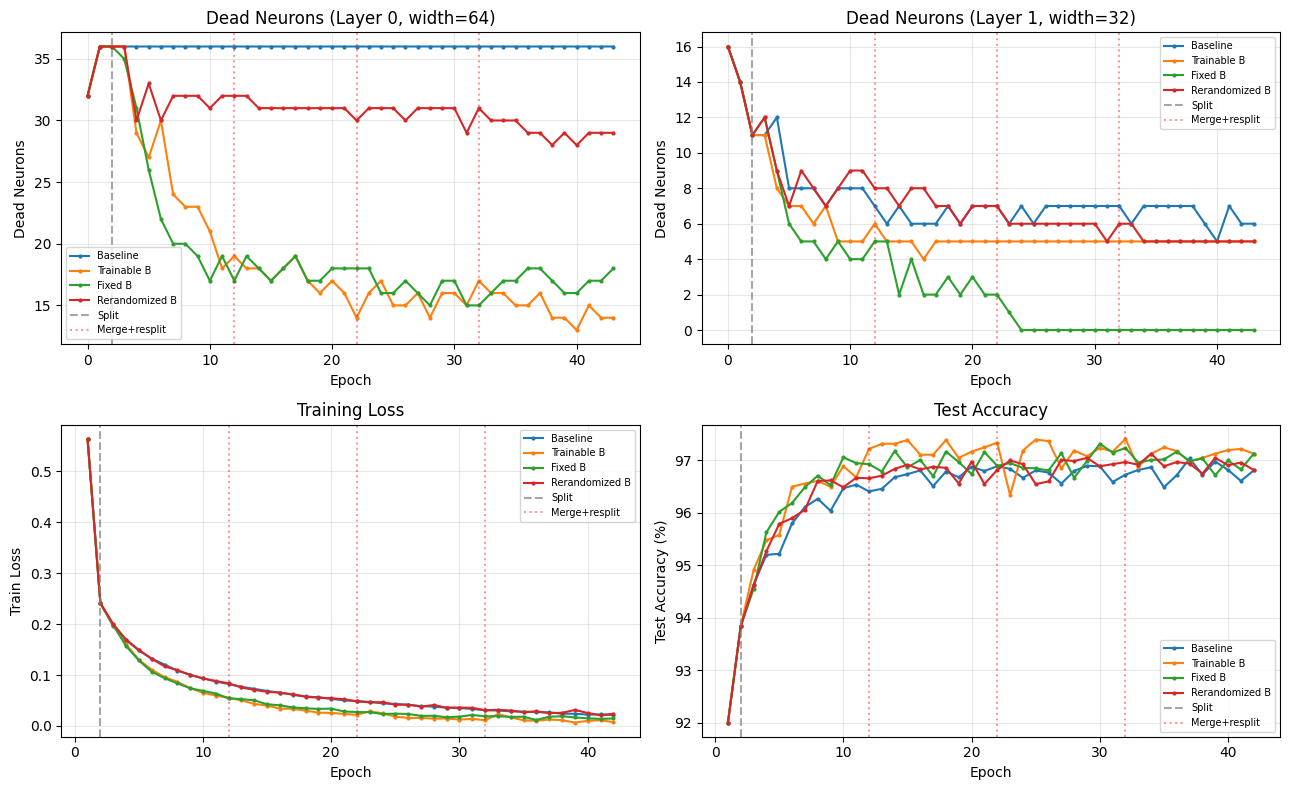

In [11]:
def full_dead_timeseries(warmup_dead, post_result, layer_idx=0):
    warmup = [dc[layer_idx][0] for dc in warmup_dead]
    post = [dc[layer_idx][0] for dc in post_result["dead_counts"]]
    return warmup + post

def full_acc_timeseries(warmup_accs, post_result):
    return warmup_accs + post_result["test_accs"]

def full_loss_timeseries(warmup_losses, post_result):
    return warmup_losses + post_result["train_losses"]

experiments = {
    "Baseline": baseline,
    "Trainable B": split_trainable,
    "Fixed B": split_fixed,
    "Rerandomized B": split_rerand,
}

split_epoch = WARMUP_EPOCHS
merge_epochs = [WARMUP_EPOCHS + e for e in range(MERGE_EVERY, POST_EPOCHS, MERGE_EVERY)]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

def add_event_lines(ax):
    ax.axvline(x=split_epoch, color="gray", linestyle="--", alpha=0.7, label="Split")
    for i, me in enumerate(merge_epochs):
        ax.axvline(x=me, color="red", linestyle=":", alpha=0.4,
                   label="Merge+resplit" if i == 0 else None)

# Dead neurons layer 0
ax = axes[0, 0]
for name, result in experiments.items():
    ts = full_dead_timeseries(warmup_dead, result, 0)
    ax.plot(range(len(ts)), ts, label=name, marker="o", markersize=2)
add_event_lines(ax)
ax.set_xlabel("Epoch")
ax.set_ylabel("Dead Neurons")
ax.set_title("Dead Neurons (Layer 0, width=64)")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Dead neurons layer 1
ax = axes[0, 1]
for name, result in experiments.items():
    ts = full_dead_timeseries(warmup_dead, result, 1)
    ax.plot(range(len(ts)), ts, label=name, marker="o", markersize=2)
add_event_lines(ax)
ax.set_xlabel("Epoch")
ax.set_ylabel("Dead Neurons")
ax.set_title("Dead Neurons (Layer 1, width=32)")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Train loss
ax = axes[1, 0]
for name, result in experiments.items():
    ts = full_loss_timeseries(warmup_losses, result)
    ax.plot(range(1, len(ts) + 1), ts, label=name, marker="o", markersize=2)
add_event_lines(ax)
ax.set_xlabel("Epoch")
ax.set_ylabel("Train Loss")
ax.set_title("Training Loss")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Test accuracy
ax = axes[1, 1]
for name, result in experiments.items():
    ts = full_acc_timeseries(warmup_accs, result)
    ax.plot(range(1, len(ts) + 1), [100 * a for a in ts], label=name, marker="o", markersize=2)
add_event_lines(ax)
ax.set_xlabel("Epoch")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Test Accuracy")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fixed_vs_trainable_B.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

All split experiments start from the same checkpoint with $C = 0$ (identical function).

- **Baseline**: no coupling, dead neurons stuck
- **Trainable B**: B adapts to the loss landscape, coupling structure is learned
- **Fixed B**: coupling directions are random but stable — tests whether learned coupling matters
- **Rerandomized B**: coupling directions change every epoch — tests whether consistent coupling directions matter

If fixed-B works nearly as well as trainable-B, then the coupling mechanism is robust to the choice of directions — what matters is having *any* off-diagonal coupling, not the specific structure.